# **Graph Metrics (*Correlation*)**

## 📦 **Package Import**

In [47]:
# python
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path

# algorithms4pepprotgraphs framework
sys.path.append('/home/jovyan/work/algorithms4pepprotgraphs')
from algorithms4pepprotgraphs.module.notebook import NotebookApp
from algorithms4pepprotgraphs.util.plotting import heatmap

app = NotebookApp('.env.jupyter.AVPDiscover')
paths = app.paths()

[2025-03-26 20:23:39,922] INFO [notebook.py:51] Setting:
dataset_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/StarPep/StarPep.csv
pdb_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/StarPep/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/Test/Test2
sequence_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/Test/2025-03-26T16.46.30-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/Test/2025-03-26T16.49.29-Graph_Analyzer


## 📊 **Data Analysis**

### **Data**

In [37]:
data = pd.read_csv(app.graph_analysis['graph_metrics'])
data["distance_interval"] = data["distance_function"] + " " + data["interval"].astype(str)
columns = [
    "sequence", "distance_interval", "number_of_nodes", "number_of_edges", 
    "density", "number_of_connected_components", "diameter", "degree_centrality", 
    "eigenvector_centrality", "closeness_centrality", "betweenness_centrality", 
    "harmonic_centrality"
]

data[columns].head()

,sequence,distance_interval,number_of_nodes,number_of_edges,density,number_of_connected_components,diameter,degree_centrality,eigenvector_centrality,closeness_centrality,betweenness_centrality,harmonic_centrality
0,LQQLLFIAFRIGRRRRRRRR,"euclidean (0, 10)",20,98,0.515789,1,4.0,0.515789,0.215785,0.622901,0.035673,13.908333
1,LAQLLFIHFRIGRRRRRRRR,"euclidean (0, 10)",20,99,0.521053,1,4.0,0.521053,0.215579,0.627122,0.035088,13.975000
2,IIRILQQLLFIHFRIGRRRRRRRR,"euclidean (0, 10)",24,122,0.442029,1,4.0,0.442029,0.195400,0.551131,0.039196,15.527778
3,LQQLLFIHFAIGRRRRRRRR,"euclidean (0, 10)",20,97,0.510526,1,4.0,0.510526,0.216144,0.615417,0.036842,13.816667
4,LQQLLFIHFRAGRRRRRRRR,"euclidean (0, 10)",20,96,0.505263,1,4.0,0.505263,0.216455,0.611196,0.037427,13.750000


### **Distance Intervals**

In [3]:
display(Markdown("\n".join(f"- {val}" for val in data['distance_interval'].unique())))

- euclidean (0, 10)
- euclidean (0, 15)
- euclidean (0, 20)
- canberra (0, 0.6155)
- canberra (0, 1.0142)
- canberra (0, 1.4712)
- lance_williams (0, 0.1789)
- lance_williams (0, 0.3041)
- lance_williams (0, 0.4664)
- clark (0, 0.4161)
- clark (0, 0.6813)
- clark (0, 0.983)
- soergel (0, 0.3035)
- soergel (0, 0.4664)
- soergel (0, 0.6357)
- bhattacharyya (0, 1.5158)
- bhattacharyya (0, 2.4304)
- bhattacharyya (0, 3.6452)
- angular_separation (0, 0.018)
- angular_separation (0, 0.0654)
- angular_separation (0, 0.1799)

### **Metrics Correlation Analysis (*All Distance Intervals*)**

<br>Number of data points: 148951

<br>Correlation (*All Distance Intervals*)

|                        |   number_of_nodes |   number_of_edges |    density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|-----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |         0.829042  | -0.259173  |  0.27204   |          -0.259173  |                -0.823402 |              -0.227622 |                -0.319435 |             0.918232  |
| number_of_edges        |          0.829042 |         1         |  0.132732  | -0.0879082 |           0.132732  |                -0.534894 |               0.15281  |                -0.358566 |             0.945167  |
| density                |         -0.259173 |         0.132732  |  1         | -0.815806  |           1         |                 0.442337 |               0.985163 |                -0.557628 |             0.0714702 |
| diameter               |          0.27204  |        -0.0879082 | -0.815806  |  1         |          -0.815806  |                -0.438333 |              -0.877716 |                 0.514723 |            -0.0516808 |
| degree_centrality      |         -0.259173 |         0.132732  |  1         | -0.815806  |           1         |                 0.442337 |               0.985163 |                -0.557628 |             0.0714702 |
| eigenvector_centrality |         -0.823402 |        -0.534894  |  0.442337  | -0.438333  |           0.442337  |                 1        |               0.426713 |                 0.260159 |            -0.713912  |
| closeness_centrality   |         -0.227622 |         0.15281   |  0.985163  | -0.877716  |           0.985163  |                 0.426713 |               1        |                -0.602587 |             0.106125  |
| betweenness_centrality |         -0.319435 |        -0.358566  | -0.557628  |  0.514723  |          -0.557628  |                 0.260159 |              -0.602587 |                 1        |            -0.478028  |
| harmonic_centrality    |          0.918232 |         0.945167  |  0.0714702 | -0.0516808 |           0.0714702 |                -0.713912 |               0.106125 |                -0.478028 |             1         |

<br>

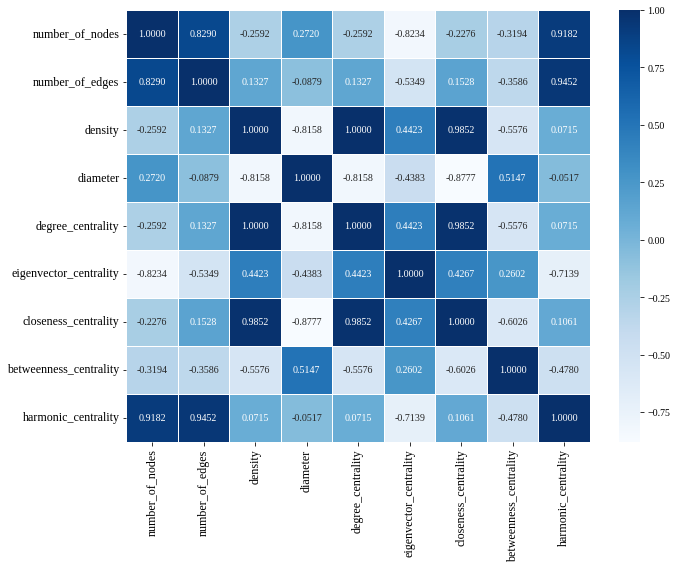

In [25]:
current_data = data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])
# current_data = current_data.dropna()
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation (*All Distance Intervals*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (all_distance_intervals) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

In [21]:
### **Metrics Correlation Analysis (*per Distance Function*)**

#### **Euclidean (*All Distance Interval*)**

<br>Number of data points: 53666

<br>Correlation Matrix (*Euclidean*)

|                        |   number_of_nodes |   number_of_edges |    density |    diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|-----------:|------------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |        0.802694   | -0.499683  |  0.435093   |          -0.499683  |               -0.832526  |             -0.46051   |               -0.12219   |             0.888234  |
| number_of_edges        |          0.802694 |        1          | -0.0716717 | -0.00614701 |          -0.0716717 |               -0.547253  |             -0.0260394 |               -0.35032   |             0.945101  |
| density                |         -0.499683 |       -0.0716717  |  1         | -0.834081   |           1         |                0.666497  |              0.988973  |               -0.69178   |            -0.162979  |
| diameter               |          0.435093 |       -0.00614701 | -0.834081  |  1          |          -0.834081  |               -0.565106  |             -0.889233  |                0.687461  |             0.0504214 |
| degree_centrality      |         -0.499683 |       -0.0716717  |  1         | -0.834081   |           1         |                0.666497  |              0.988973  |               -0.69178   |            -0.162979  |
| eigenvector_centrality |         -0.832526 |       -0.547253   |  0.666497  | -0.565106   |           0.666497  |                1         |              0.641424  |               -0.0840468 |            -0.718451  |
| closeness_centrality   |         -0.46051  |       -0.0260394  |  0.988973  | -0.889233   |           0.988973  |                0.641424  |              1         |               -0.741058  |            -0.105791  |
| betweenness_centrality |         -0.12219  |       -0.35032    | -0.69178   |  0.687461   |          -0.69178   |               -0.0840468 |             -0.741058  |                1         |            -0.404376  |
| harmonic_centrality    |          0.888234 |        0.945101   | -0.162979  |  0.0504214  |          -0.162979  |               -0.718451  |             -0.105791  |               -0.404376  |             1         |

<br>

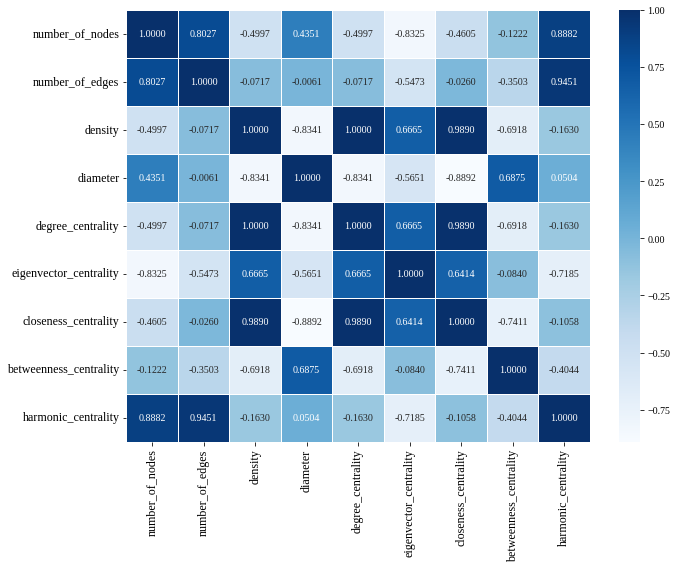

In [33]:
distance_function = 'euclidean'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])
# current_data = current_data.dropna()
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Euclidean*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (eu) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)

#### **25th percentile**

<br>Number of data points: 17888

<br>Correlation Matrix (*Euclidean 25th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.951402 | -0.726248 |   0.616159 |           -0.726248 |               -0.826663  |              -0.655155 |               -0.294829  |              0.935442 |
| number_of_edges        |          0.951402 |          1        | -0.569831 |   0.390363 |           -0.569831 |               -0.717239  |              -0.459986 |               -0.474276  |              0.97809  |
| density                |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| diameter               |          0.616159 |          0.390363 | -0.765701 |   1        |           -0.765701 |               -0.699323  |              -0.862945 |                0.399477  |              0.363075 |
| degree_centrality      |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| eigenvector_centrality |         -0.826663 |         -0.717239 |  0.901196 |  -0.699323 |            0.901196 |                1         |               0.852577 |                0.0824432 |             -0.789565 |
| closeness_centrality   |         -0.655155 |         -0.459986 |  0.97078  |  -0.862945 |            0.97078  |                0.852577  |               1        |               -0.410551  |             -0.489763 |
| betweenness_centrality |         -0.294829 |         -0.474276 | -0.276351 |   0.399477 |           -0.276351 |                0.0824432 |              -0.410551 |                1         |             -0.515771 |
| harmonic_centrality    |          0.935442 |          0.97809  | -0.618186 |   0.363075 |           -0.618186 |               -0.789565  |              -0.489763 |               -0.515771  |              1        |

<br>

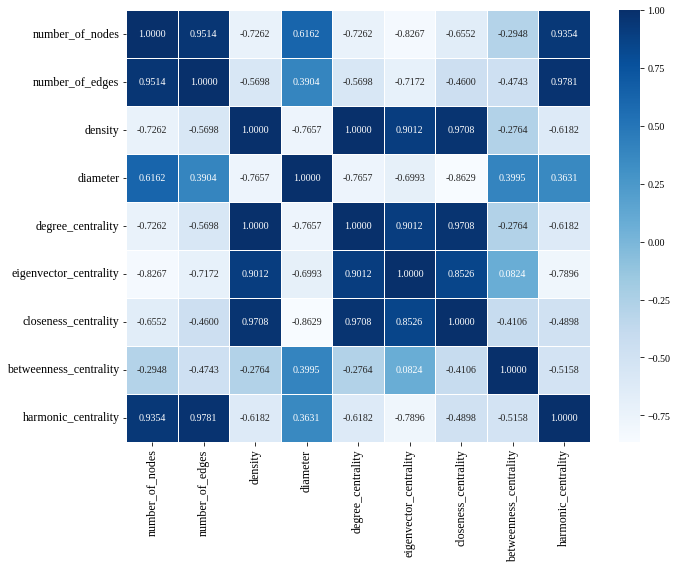

In [43]:
distance_intervals = [
    'euclidean (0, 10)' 
]

distance_function = 'euclidean'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Euclidean 25th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (eu_p25) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **50th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 50th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.923347 | -0.666278 |   0.549386 |           -0.666278 |               -0.84011   |              -0.611126 |               -0.141032  |              0.955633 |
| number_of_edges        |          0.923347 |          1        | -0.419797 |   0.265975 |           -0.419797 |               -0.67485   |              -0.341435 |               -0.327691  |              0.965967 |
| density                |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| diameter               |          0.549386 |          0.265975 | -0.848733 |   1        |           -0.848733 |               -0.652225  |              -0.903341 |                0.580956  |              0.339196 |
| degree_centrality      |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| eigenvector_centrality |         -0.84011  |         -0.67485  |  0.809435 |  -0.652225 |            0.809435 |                1         |               0.769843 |               -0.0935803 |             -0.814468 |
| closeness_centrality   |         -0.611126 |         -0.341435 |  0.986711 |  -0.903341 |            0.986711 |                0.769843  |               1        |               -0.628964  |             -0.440111 |
| betweenness_centrality |         -0.141032 |         -0.327691 | -0.569603 |   0.580956 |           -0.569603 |               -0.0935803 |              -0.628964 |                1         |             -0.312402 |
| harmonic_centrality    |          0.955633 |          0.965967 | -0.520454 |   0.339196 |           -0.520454 |               -0.814468  |              -0.440111 |               -0.312402  |              1        |

<br>

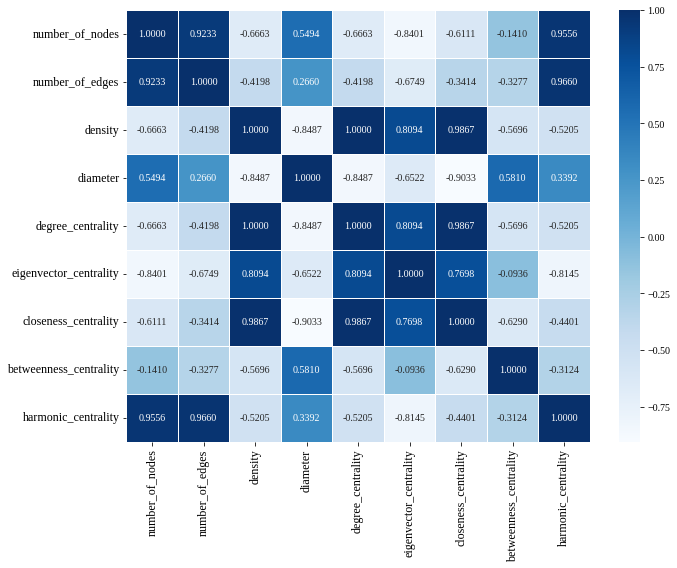

In [46]:
distance_intervals = [
    'euclidean (0, 15)' 
]

distance_function = 'euclidean'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Euclidean 50th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (eu_p50) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **75th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 75th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |         1         |          0.918804 | -0.568517 |   0.511931 |           -0.568517 |                -0.844    |              -0.549926 |               -0.0323088 |              0.968408 |
| number_of_edges        |         0.918804  |          1        | -0.299105 |   0.233424 |           -0.299105 |                -0.659664 |              -0.272314 |               -0.223373  |              0.956321 |
| density                |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| diameter               |         0.511931  |          0.233424 | -0.88061  |   1        |           -0.88061  |                -0.617536 |              -0.904459 |                0.6721    |              0.339523 |
| degree_centrality      |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| eigenvector_centrality |        -0.844     |         -0.659664 |  0.672539 |  -0.617536 |            0.672539 |                 1        |               0.660708 |               -0.18195   |             -0.826768 |
| closeness_centrality   |        -0.549926  |         -0.272314 |  0.995555 |  -0.904459 |            0.995555 |                 0.660708 |               1        |               -0.758946  |             -0.381077 |
| betweenness_centrality |        -0.0323088 |         -0.223373 | -0.743344 |   0.6721   |           -0.743344 |                -0.18195  |              -0.758946 |                1         |             -0.181099 |
| harmonic_centrality    |         0.968408  |          0.956321 | -0.406749 |   0.339523 |           -0.406749 |                -0.826768 |              -0.381077 |               -0.181099  |              1        |

<br>

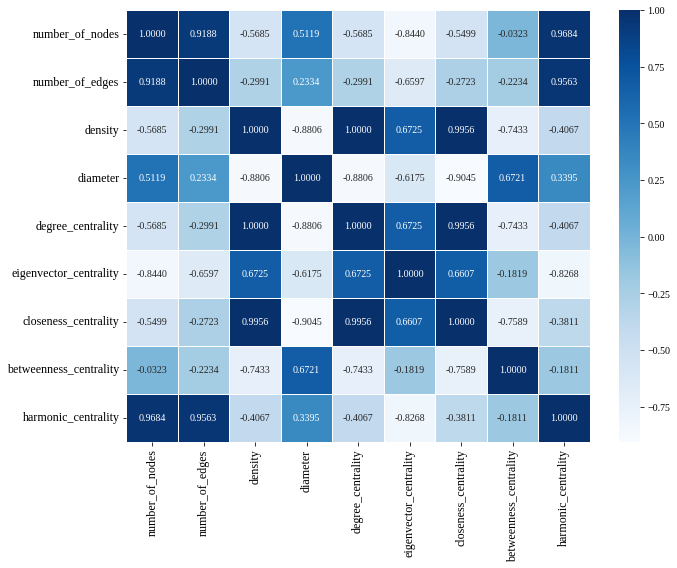

In [45]:
distance_intervals = [
    'euclidean (0, 20)' 
]

distance_function = 'euclidean'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Euclidean 75th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (eu_p75) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **Bhattacharyya**

<br>Number of data points: 36063

<br>Correlation Matrix (*Bhattacharyya*)

|                        |   number_of_nodes |   number_of_edges |    density |    diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|-----------:|------------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |        0.86026    | -0.32781   |  0.32271    |          -0.32781   |                -0.832785 |             -0.294374  |                -0.365717 |             0.941946  |
| number_of_edges        |          0.86026  |        1          |  0.0235308 | -0.00840024 |           0.0235308 |                -0.575878 |              0.0503054 |                -0.38767  |             0.944704  |
| density                |         -0.32781  |        0.0235308  |  1         | -0.852238   |           1         |                 0.464276 |              0.989301  |                -0.507331 |            -0.051008  |
| diameter               |          0.32271  |       -0.00840024 | -0.852238  |  1          |          -0.852238  |                -0.458085 |             -0.897508  |                 0.448847 |             0.0527249 |
| degree_centrality      |         -0.32781  |        0.0235308  |  1         | -0.852238   |           1         |                 0.464276 |              0.989301  |                -0.507331 |            -0.051008  |
| eigenvector_centrality |         -0.832785 |       -0.575878   |  0.464276  | -0.458085   |           0.464276  |                 1        |              0.447199  |                 0.355213 |            -0.761854  |
| closeness_centrality   |         -0.294374 |        0.0503054  |  0.989301  | -0.897508   |           0.989301  |                 0.447199 |              1         |                -0.545049 |            -0.0148741 |
| betweenness_centrality |         -0.365717 |       -0.38767    | -0.507331  |  0.448847   |          -0.507331  |                 0.355213 |             -0.545049  |                 1        |            -0.509069  |
| harmonic_centrality    |          0.941946 |        0.944704   | -0.051008  |  0.0527249  |          -0.051008  |                -0.761854 |             -0.0148741 |                -0.509069 |             1         |

<br>

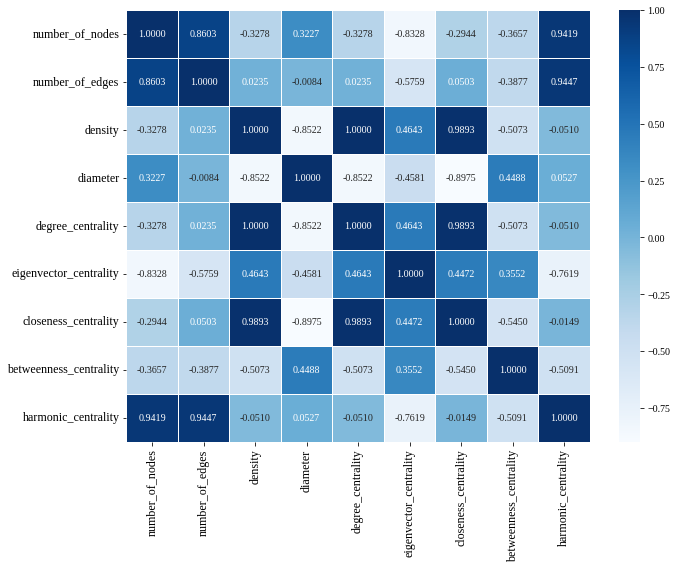

In [26]:
distance_function = 'bhattacharyya'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Bhattacharyya*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (ba) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)

#### **25th percentile**

<br>Number of data points: 17888

<br>Correlation Matrix (*Euclidean 25th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.951402 | -0.726248 |   0.616159 |           -0.726248 |               -0.826663  |              -0.655155 |               -0.294829  |              0.935442 |
| number_of_edges        |          0.951402 |          1        | -0.569831 |   0.390363 |           -0.569831 |               -0.717239  |              -0.459986 |               -0.474276  |              0.97809  |
| density                |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| diameter               |          0.616159 |          0.390363 | -0.765701 |   1        |           -0.765701 |               -0.699323  |              -0.862945 |                0.399477  |              0.363075 |
| degree_centrality      |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| eigenvector_centrality |         -0.826663 |         -0.717239 |  0.901196 |  -0.699323 |            0.901196 |                1         |               0.852577 |                0.0824432 |             -0.789565 |
| closeness_centrality   |         -0.655155 |         -0.459986 |  0.97078  |  -0.862945 |            0.97078  |                0.852577  |               1        |               -0.410551  |             -0.489763 |
| betweenness_centrality |         -0.294829 |         -0.474276 | -0.276351 |   0.399477 |           -0.276351 |                0.0824432 |              -0.410551 |                1         |             -0.515771 |
| harmonic_centrality    |          0.935442 |          0.97809  | -0.618186 |   0.363075 |           -0.618186 |               -0.789565  |              -0.489763 |               -0.515771  |              1        |

<br>

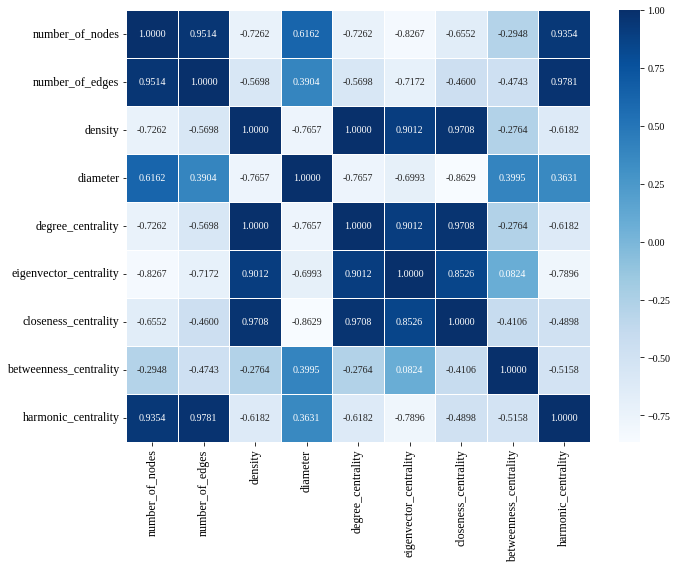

In [43]:
distance_intervals = [
    'bhattacharyya (0, 10)' 
]

distance_function = 'bhattacharyya'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])

current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Bhattacharyya 25th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (ba_p25) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **50th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 50th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.923347 | -0.666278 |   0.549386 |           -0.666278 |               -0.84011   |              -0.611126 |               -0.141032  |              0.955633 |
| number_of_edges        |          0.923347 |          1        | -0.419797 |   0.265975 |           -0.419797 |               -0.67485   |              -0.341435 |               -0.327691  |              0.965967 |
| density                |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| diameter               |          0.549386 |          0.265975 | -0.848733 |   1        |           -0.848733 |               -0.652225  |              -0.903341 |                0.580956  |              0.339196 |
| degree_centrality      |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| eigenvector_centrality |         -0.84011  |         -0.67485  |  0.809435 |  -0.652225 |            0.809435 |                1         |               0.769843 |               -0.0935803 |             -0.814468 |
| closeness_centrality   |         -0.611126 |         -0.341435 |  0.986711 |  -0.903341 |            0.986711 |                0.769843  |               1        |               -0.628964  |             -0.440111 |
| betweenness_centrality |         -0.141032 |         -0.327691 | -0.569603 |   0.580956 |           -0.569603 |               -0.0935803 |              -0.628964 |                1         |             -0.312402 |
| harmonic_centrality    |          0.955633 |          0.965967 | -0.520454 |   0.339196 |           -0.520454 |               -0.814468  |              -0.440111 |               -0.312402  |              1        |

<br>

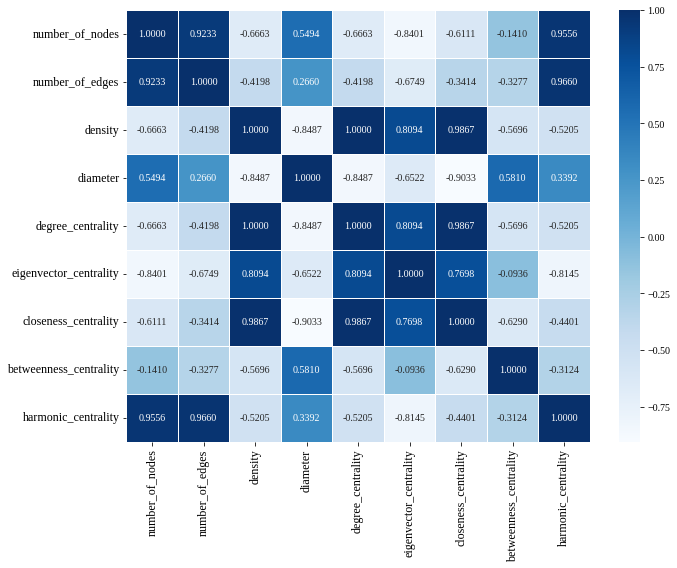

In [46]:
distance_intervals = [
    'bhattacharyya (0, 15)' 
]

distance_function = 'bhattacharyya'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])

current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Bhattacharyya 50th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (ba_p50) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **75th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 75th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |         1         |          0.918804 | -0.568517 |   0.511931 |           -0.568517 |                -0.844    |              -0.549926 |               -0.0323088 |              0.968408 |
| number_of_edges        |         0.918804  |          1        | -0.299105 |   0.233424 |           -0.299105 |                -0.659664 |              -0.272314 |               -0.223373  |              0.956321 |
| density                |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| diameter               |         0.511931  |          0.233424 | -0.88061  |   1        |           -0.88061  |                -0.617536 |              -0.904459 |                0.6721    |              0.339523 |
| degree_centrality      |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| eigenvector_centrality |        -0.844     |         -0.659664 |  0.672539 |  -0.617536 |            0.672539 |                 1        |               0.660708 |               -0.18195   |             -0.826768 |
| closeness_centrality   |        -0.549926  |         -0.272314 |  0.995555 |  -0.904459 |            0.995555 |                 0.660708 |               1        |               -0.758946  |             -0.381077 |
| betweenness_centrality |        -0.0323088 |         -0.223373 | -0.743344 |   0.6721   |           -0.743344 |                -0.18195  |              -0.758946 |                1         |             -0.181099 |
| harmonic_centrality    |         0.968408  |          0.956321 | -0.406749 |   0.339523 |           -0.406749 |                -0.826768 |              -0.381077 |               -0.181099  |              1        |

<br>

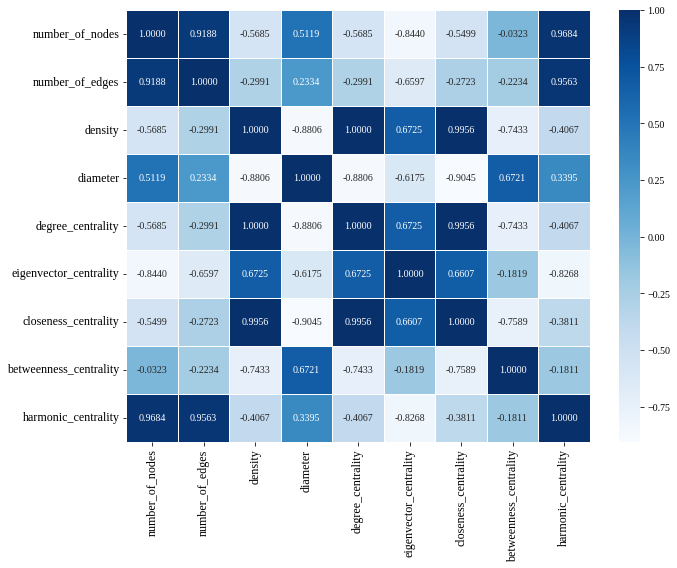

In [45]:
distance_intervals = [
    'bhattacharyya (0, 20)' 
]

distance_function = 'bhattacharyya'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Bhattacharyya 75th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (ba_p75) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **Canberra**

<br>Number of data points: 6082

<br>Correlation Matrix (*Canberra*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.950937 |  0.566841 | -0.158785  |            0.566841 |               -0.828179  |               0.551217 |                -0.561191 |              0.995429 |
| number_of_edges        |          0.950937 |          1        |  0.558226 | -0.21061   |            0.558226 |               -0.652956  |               0.551247 |                -0.400156 |              0.96285  |
| density                |          0.566841 |          0.558226 |  1        | -0.488134  |            1        |               -0.484621  |               0.988623 |                -0.622547 |              0.626407 |
| diameter               |         -0.158785 |         -0.21061  | -0.488134 |  1         |           -0.488134 |                0.0220212 |              -0.551384 |                 0.173324 |             -0.206239 |
| degree_centrality      |          0.566841 |          0.558226 |  1        | -0.488134  |            1        |               -0.484621  |               0.988623 |                -0.622547 |              0.626407 |
| eigenvector_centrality |         -0.828179 |         -0.652956 | -0.484621 |  0.0220212 |           -0.484621 |                1         |              -0.452694 |                 0.818249 |             -0.807058 |
| closeness_centrality   |          0.551217 |          0.551247 |  0.988623 | -0.551384  |            0.988623 |               -0.452694  |               1        |                -0.605124 |              0.612994 |
| betweenness_centrality |         -0.561191 |         -0.400156 | -0.622547 |  0.173324  |           -0.622547 |                0.818249  |              -0.605124 |                 1        |             -0.558165 |
| harmonic_centrality    |          0.995429 |          0.96285  |  0.626407 | -0.206239  |            0.626407 |               -0.807058  |               0.612994 |                -0.558165 |              1        |

<br>

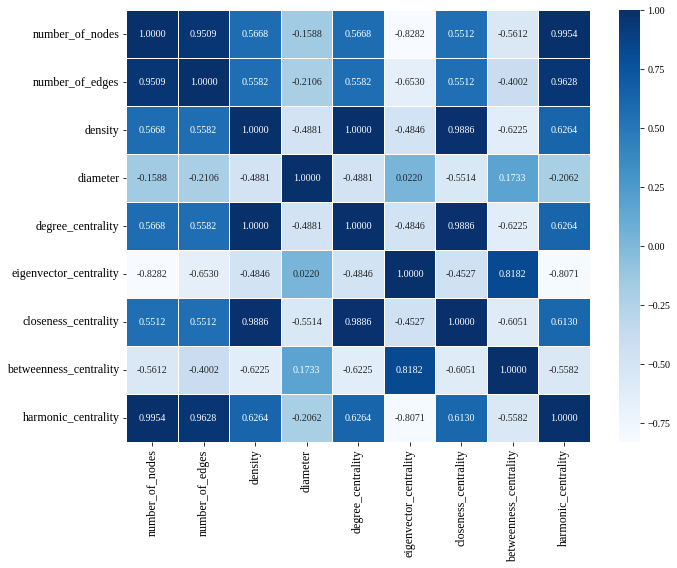

In [27]:
distance_function = 'canberra'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])
# current_data = current_data.dropna()
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Canberra*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (ca) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)

#### **25th percentile**

<br>Number of data points: 17888

<br>Correlation Matrix (*Euclidean 25th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.951402 | -0.726248 |   0.616159 |           -0.726248 |               -0.826663  |              -0.655155 |               -0.294829  |              0.935442 |
| number_of_edges        |          0.951402 |          1        | -0.569831 |   0.390363 |           -0.569831 |               -0.717239  |              -0.459986 |               -0.474276  |              0.97809  |
| density                |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| diameter               |          0.616159 |          0.390363 | -0.765701 |   1        |           -0.765701 |               -0.699323  |              -0.862945 |                0.399477  |              0.363075 |
| degree_centrality      |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| eigenvector_centrality |         -0.826663 |         -0.717239 |  0.901196 |  -0.699323 |            0.901196 |                1         |               0.852577 |                0.0824432 |             -0.789565 |
| closeness_centrality   |         -0.655155 |         -0.459986 |  0.97078  |  -0.862945 |            0.97078  |                0.852577  |               1        |               -0.410551  |             -0.489763 |
| betweenness_centrality |         -0.294829 |         -0.474276 | -0.276351 |   0.399477 |           -0.276351 |                0.0824432 |              -0.410551 |                1         |             -0.515771 |
| harmonic_centrality    |          0.935442 |          0.97809  | -0.618186 |   0.363075 |           -0.618186 |               -0.789565  |              -0.489763 |               -0.515771  |              1        |

<br>

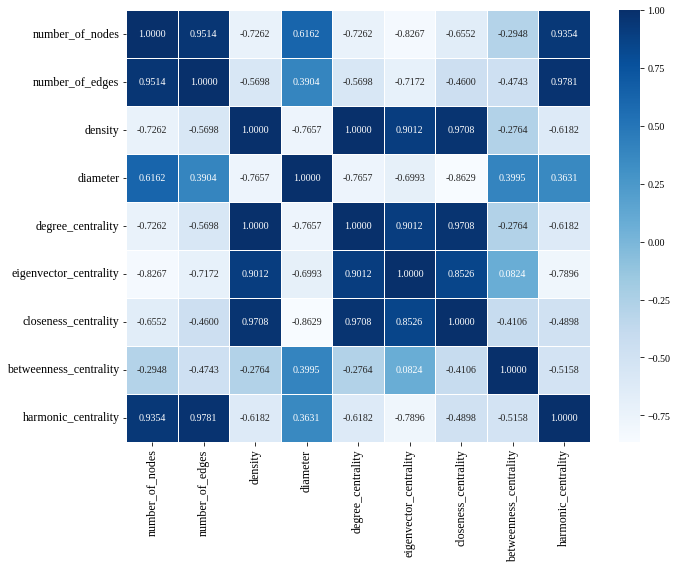

In [43]:
distance_intervals = [
    'euclidean (0, 10)' 
]

distance_function = 'canberra'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Canberra 25th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (ca_p25) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **50th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 50th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.923347 | -0.666278 |   0.549386 |           -0.666278 |               -0.84011   |              -0.611126 |               -0.141032  |              0.955633 |
| number_of_edges        |          0.923347 |          1        | -0.419797 |   0.265975 |           -0.419797 |               -0.67485   |              -0.341435 |               -0.327691  |              0.965967 |
| density                |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| diameter               |          0.549386 |          0.265975 | -0.848733 |   1        |           -0.848733 |               -0.652225  |              -0.903341 |                0.580956  |              0.339196 |
| degree_centrality      |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| eigenvector_centrality |         -0.84011  |         -0.67485  |  0.809435 |  -0.652225 |            0.809435 |                1         |               0.769843 |               -0.0935803 |             -0.814468 |
| closeness_centrality   |         -0.611126 |         -0.341435 |  0.986711 |  -0.903341 |            0.986711 |                0.769843  |               1        |               -0.628964  |             -0.440111 |
| betweenness_centrality |         -0.141032 |         -0.327691 | -0.569603 |   0.580956 |           -0.569603 |               -0.0935803 |              -0.628964 |                1         |             -0.312402 |
| harmonic_centrality    |          0.955633 |          0.965967 | -0.520454 |   0.339196 |           -0.520454 |               -0.814468  |              -0.440111 |               -0.312402  |              1        |

<br>

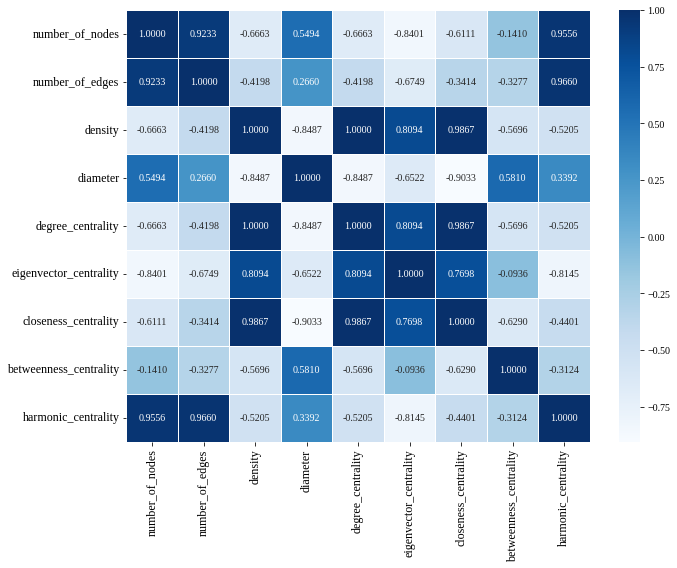

In [46]:
distance_intervals = [
    'canberra (0, 15)' 
]

distance_function = 'canberra'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Canberra 50th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (ca_p50) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **75th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 75th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |         1         |          0.918804 | -0.568517 |   0.511931 |           -0.568517 |                -0.844    |              -0.549926 |               -0.0323088 |              0.968408 |
| number_of_edges        |         0.918804  |          1        | -0.299105 |   0.233424 |           -0.299105 |                -0.659664 |              -0.272314 |               -0.223373  |              0.956321 |
| density                |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| diameter               |         0.511931  |          0.233424 | -0.88061  |   1        |           -0.88061  |                -0.617536 |              -0.904459 |                0.6721    |              0.339523 |
| degree_centrality      |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| eigenvector_centrality |        -0.844     |         -0.659664 |  0.672539 |  -0.617536 |            0.672539 |                 1        |               0.660708 |               -0.18195   |             -0.826768 |
| closeness_centrality   |        -0.549926  |         -0.272314 |  0.995555 |  -0.904459 |            0.995555 |                 0.660708 |               1        |               -0.758946  |             -0.381077 |
| betweenness_centrality |        -0.0323088 |         -0.223373 | -0.743344 |   0.6721   |           -0.743344 |                -0.18195  |              -0.758946 |                1         |             -0.181099 |
| harmonic_centrality    |         0.968408  |          0.956321 | -0.406749 |   0.339523 |           -0.406749 |                -0.826768 |              -0.381077 |               -0.181099  |              1        |

<br>

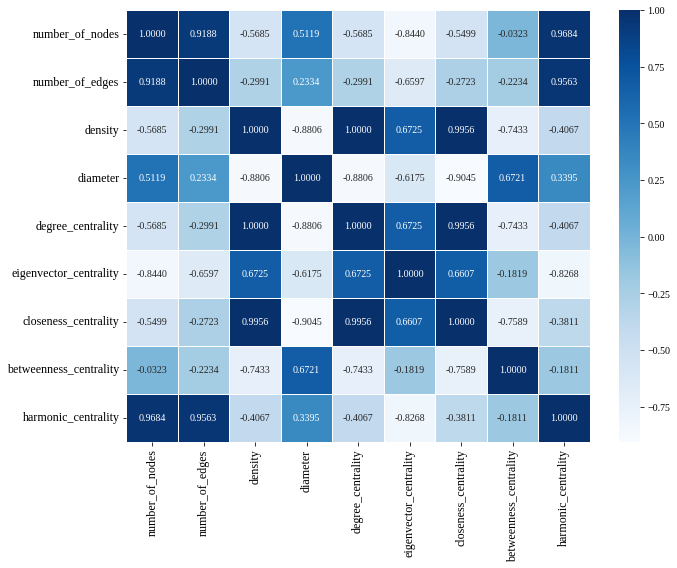

In [45]:
distance_intervals = [
    'canberra (0, 20)' 
]

distance_function = 'canberra'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Canberra 75th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (ca_p75) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **Clark**

<br>Number of data points: 53667

<br>Correlation Matrix (*Clark*)

|                        |   number_of_nodes |   number_of_edges |   density |   degree_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|--------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.82193  |  0.202611 |            0.202611 |               0.281276 |                -0.193222 |              0.902362 |
| number_of_edges        |          0.82193  |          1        |  0.417442 |            0.417442 |               0.44707  |                -0.312258 |              0.932955 |
| density                |          0.202611 |          0.417442 |  1        |            1        |               0.987334 |                -0.530367 |              0.539174 |
| degree_centrality      |          0.202611 |          0.417442 |  1        |            1        |               0.987334 |                -0.530367 |              0.539174 |
| closeness_centrality   |          0.281276 |          0.44707  |  0.987334 |            0.987334 |               1        |                -0.48623  |              0.594615 |
| betweenness_centrality |         -0.193222 |         -0.312258 | -0.530367 |           -0.530367 |              -0.48623  |                 1        |             -0.355864 |
| harmonic_centrality    |          0.902362 |          0.932955 |  0.539174 |            0.539174 |               0.594615 |                -0.355864 |              1        |

<br>

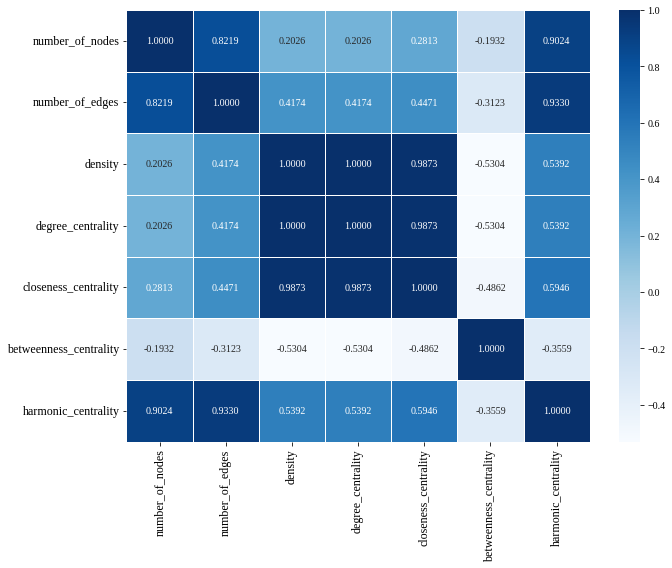

In [31]:
distance_function = 'clark'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['diameter', 'number_of_connected_components', 'eigenvector_centrality'])
# current_data = current_data.dropna(subset=['eigenvector_centrality'])
# current_data = current_data.dropna()
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Clark*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (cl) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)

#### **25th percentile**

<br>Number of data points: 17888

<br>Correlation Matrix (*Euclidean 25th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.951402 | -0.726248 |   0.616159 |           -0.726248 |               -0.826663  |              -0.655155 |               -0.294829  |              0.935442 |
| number_of_edges        |          0.951402 |          1        | -0.569831 |   0.390363 |           -0.569831 |               -0.717239  |              -0.459986 |               -0.474276  |              0.97809  |
| density                |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| diameter               |          0.616159 |          0.390363 | -0.765701 |   1        |           -0.765701 |               -0.699323  |              -0.862945 |                0.399477  |              0.363075 |
| degree_centrality      |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| eigenvector_centrality |         -0.826663 |         -0.717239 |  0.901196 |  -0.699323 |            0.901196 |                1         |               0.852577 |                0.0824432 |             -0.789565 |
| closeness_centrality   |         -0.655155 |         -0.459986 |  0.97078  |  -0.862945 |            0.97078  |                0.852577  |               1        |               -0.410551  |             -0.489763 |
| betweenness_centrality |         -0.294829 |         -0.474276 | -0.276351 |   0.399477 |           -0.276351 |                0.0824432 |              -0.410551 |                1         |             -0.515771 |
| harmonic_centrality    |          0.935442 |          0.97809  | -0.618186 |   0.363075 |           -0.618186 |               -0.789565  |              -0.489763 |               -0.515771  |              1        |

<br>

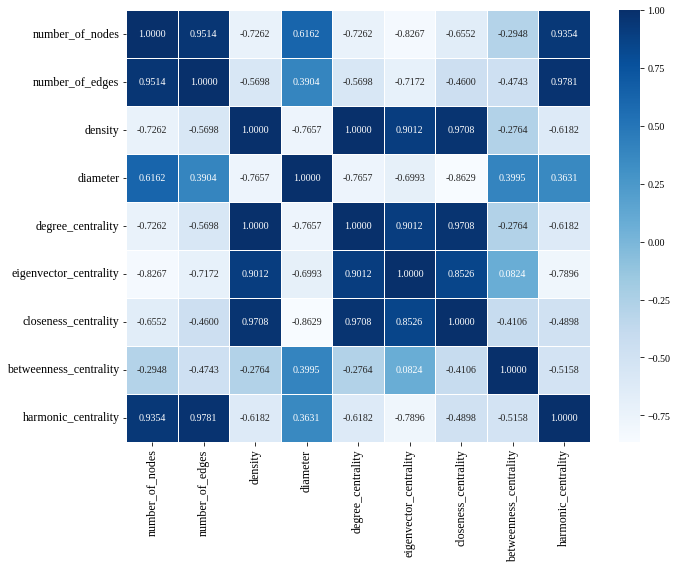

In [43]:
distance_intervals = [
    'clark (0, 10)' 
]

distance_function = 'clark'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Clark 25th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (cl_p25) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **50th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 50th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.923347 | -0.666278 |   0.549386 |           -0.666278 |               -0.84011   |              -0.611126 |               -0.141032  |              0.955633 |
| number_of_edges        |          0.923347 |          1        | -0.419797 |   0.265975 |           -0.419797 |               -0.67485   |              -0.341435 |               -0.327691  |              0.965967 |
| density                |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| diameter               |          0.549386 |          0.265975 | -0.848733 |   1        |           -0.848733 |               -0.652225  |              -0.903341 |                0.580956  |              0.339196 |
| degree_centrality      |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| eigenvector_centrality |         -0.84011  |         -0.67485  |  0.809435 |  -0.652225 |            0.809435 |                1         |               0.769843 |               -0.0935803 |             -0.814468 |
| closeness_centrality   |         -0.611126 |         -0.341435 |  0.986711 |  -0.903341 |            0.986711 |                0.769843  |               1        |               -0.628964  |             -0.440111 |
| betweenness_centrality |         -0.141032 |         -0.327691 | -0.569603 |   0.580956 |           -0.569603 |               -0.0935803 |              -0.628964 |                1         |             -0.312402 |
| harmonic_centrality    |          0.955633 |          0.965967 | -0.520454 |   0.339196 |           -0.520454 |               -0.814468  |              -0.440111 |               -0.312402  |              1        |

<br>

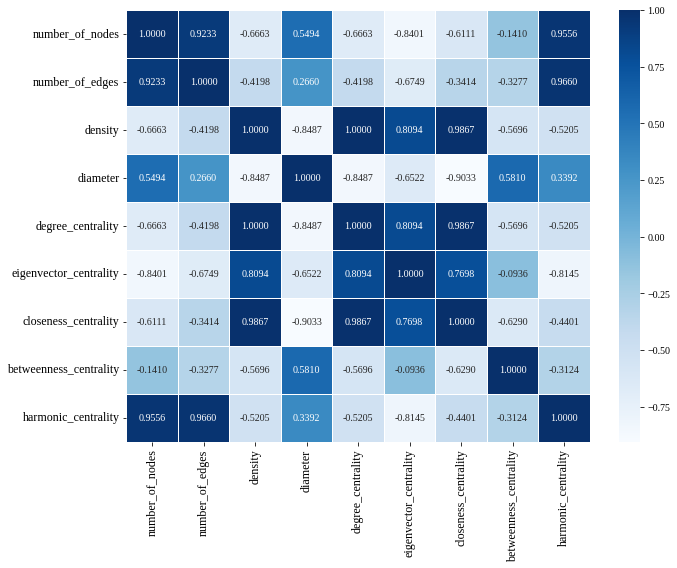

In [46]:
distance_intervals = [
    'clark (0, 15)' 
]

distance_function = 'clark'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Clark 50th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (cl_p50) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **75th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 75th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |         1         |          0.918804 | -0.568517 |   0.511931 |           -0.568517 |                -0.844    |              -0.549926 |               -0.0323088 |              0.968408 |
| number_of_edges        |         0.918804  |          1        | -0.299105 |   0.233424 |           -0.299105 |                -0.659664 |              -0.272314 |               -0.223373  |              0.956321 |
| density                |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| diameter               |         0.511931  |          0.233424 | -0.88061  |   1        |           -0.88061  |                -0.617536 |              -0.904459 |                0.6721    |              0.339523 |
| degree_centrality      |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| eigenvector_centrality |        -0.844     |         -0.659664 |  0.672539 |  -0.617536 |            0.672539 |                 1        |               0.660708 |               -0.18195   |             -0.826768 |
| closeness_centrality   |        -0.549926  |         -0.272314 |  0.995555 |  -0.904459 |            0.995555 |                 0.660708 |               1        |               -0.758946  |             -0.381077 |
| betweenness_centrality |        -0.0323088 |         -0.223373 | -0.743344 |   0.6721   |           -0.743344 |                -0.18195  |              -0.758946 |                1         |             -0.181099 |
| harmonic_centrality    |         0.968408  |          0.956321 | -0.406749 |   0.339523 |           -0.406749 |                -0.826768 |              -0.381077 |               -0.181099  |              1        |

<br>

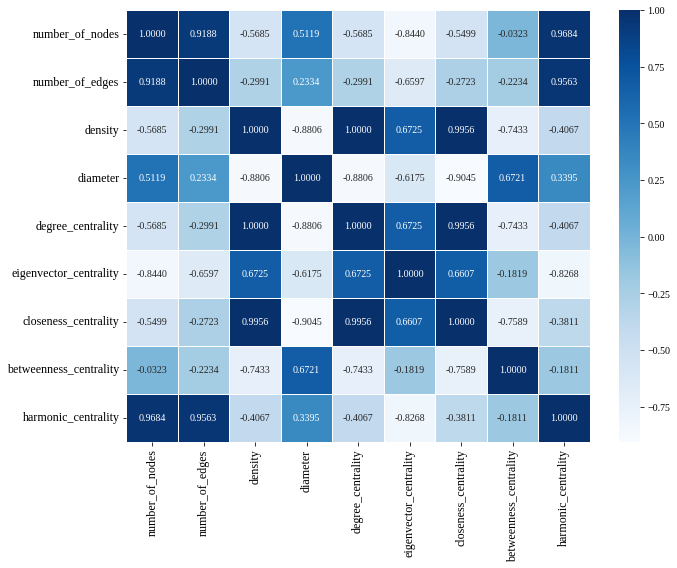

In [45]:
distance_intervals = [
    'clark (0, 20)' 
]

distance_function = 'clark'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Clark 75th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (cl_p75) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **Angular Separation**

In [ ]:
distance_function = 'angular_separation'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])
# current_data = current_data.dropna()
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Angular Separation*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (as) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)

#### **25th percentile**

<br>Number of data points: 17888

<br>Correlation Matrix (*Euclidean 25th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.951402 | -0.726248 |   0.616159 |           -0.726248 |               -0.826663  |              -0.655155 |               -0.294829  |              0.935442 |
| number_of_edges        |          0.951402 |          1        | -0.569831 |   0.390363 |           -0.569831 |               -0.717239  |              -0.459986 |               -0.474276  |              0.97809  |
| density                |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| diameter               |          0.616159 |          0.390363 | -0.765701 |   1        |           -0.765701 |               -0.699323  |              -0.862945 |                0.399477  |              0.363075 |
| degree_centrality      |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| eigenvector_centrality |         -0.826663 |         -0.717239 |  0.901196 |  -0.699323 |            0.901196 |                1         |               0.852577 |                0.0824432 |             -0.789565 |
| closeness_centrality   |         -0.655155 |         -0.459986 |  0.97078  |  -0.862945 |            0.97078  |                0.852577  |               1        |               -0.410551  |             -0.489763 |
| betweenness_centrality |         -0.294829 |         -0.474276 | -0.276351 |   0.399477 |           -0.276351 |                0.0824432 |              -0.410551 |                1         |             -0.515771 |
| harmonic_centrality    |          0.935442 |          0.97809  | -0.618186 |   0.363075 |           -0.618186 |               -0.789565  |              -0.489763 |               -0.515771  |              1        |

<br>

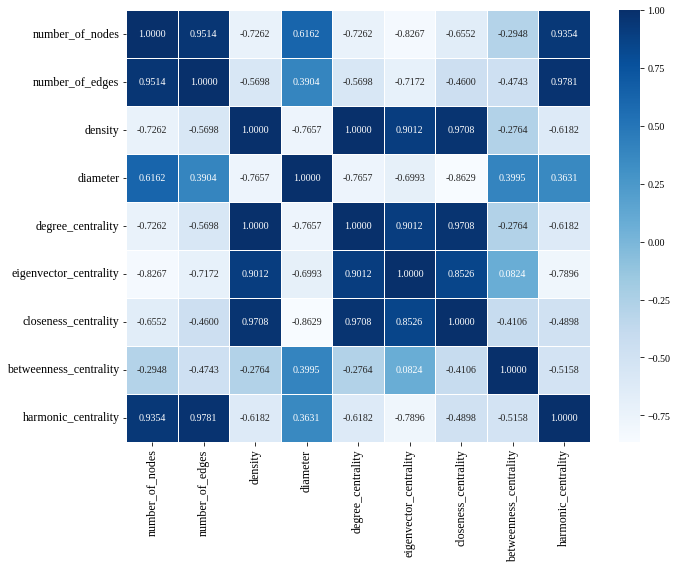

In [43]:
distance_intervals = [
    'angular_separation (0, 10)' 
]

distance_function = 'angular_separation'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Angular_Separation 25th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (as_p25) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **50th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 50th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.923347 | -0.666278 |   0.549386 |           -0.666278 |               -0.84011   |              -0.611126 |               -0.141032  |              0.955633 |
| number_of_edges        |          0.923347 |          1        | -0.419797 |   0.265975 |           -0.419797 |               -0.67485   |              -0.341435 |               -0.327691  |              0.965967 |
| density                |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| diameter               |          0.549386 |          0.265975 | -0.848733 |   1        |           -0.848733 |               -0.652225  |              -0.903341 |                0.580956  |              0.339196 |
| degree_centrality      |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| eigenvector_centrality |         -0.84011  |         -0.67485  |  0.809435 |  -0.652225 |            0.809435 |                1         |               0.769843 |               -0.0935803 |             -0.814468 |
| closeness_centrality   |         -0.611126 |         -0.341435 |  0.986711 |  -0.903341 |            0.986711 |                0.769843  |               1        |               -0.628964  |             -0.440111 |
| betweenness_centrality |         -0.141032 |         -0.327691 | -0.569603 |   0.580956 |           -0.569603 |               -0.0935803 |              -0.628964 |                1         |             -0.312402 |
| harmonic_centrality    |          0.955633 |          0.965967 | -0.520454 |   0.339196 |           -0.520454 |               -0.814468  |              -0.440111 |               -0.312402  |              1        |

<br>

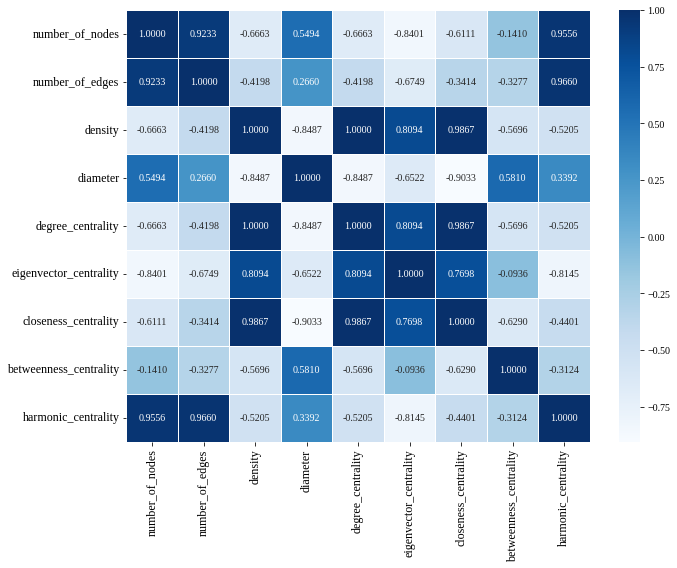

In [46]:
distance_intervals = [
    'angular_separation (0, 15)' 
]

distance_function = 'angular_separation'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Angular Separation 50th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (as_p50) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **75th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 75th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |         1         |          0.918804 | -0.568517 |   0.511931 |           -0.568517 |                -0.844    |              -0.549926 |               -0.0323088 |              0.968408 |
| number_of_edges        |         0.918804  |          1        | -0.299105 |   0.233424 |           -0.299105 |                -0.659664 |              -0.272314 |               -0.223373  |              0.956321 |
| density                |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| diameter               |         0.511931  |          0.233424 | -0.88061  |   1        |           -0.88061  |                -0.617536 |              -0.904459 |                0.6721    |              0.339523 |
| degree_centrality      |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| eigenvector_centrality |        -0.844     |         -0.659664 |  0.672539 |  -0.617536 |            0.672539 |                 1        |               0.660708 |               -0.18195   |             -0.826768 |
| closeness_centrality   |        -0.549926  |         -0.272314 |  0.995555 |  -0.904459 |            0.995555 |                 0.660708 |               1        |               -0.758946  |             -0.381077 |
| betweenness_centrality |        -0.0323088 |         -0.223373 | -0.743344 |   0.6721   |           -0.743344 |                -0.18195  |              -0.758946 |                1         |             -0.181099 |
| harmonic_centrality    |         0.968408  |          0.956321 | -0.406749 |   0.339523 |           -0.406749 |                -0.826768 |              -0.381077 |               -0.181099  |              1        |

<br>

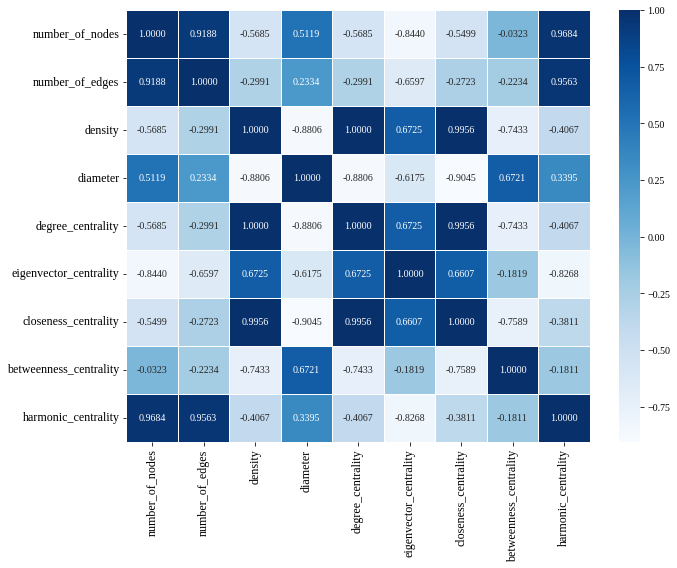

In [45]:
distance_intervals = [
    'angular_separation (0, 20)' 
]

distance_function = 'angular_separation'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Angular Separation 75th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (as_p75) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **Lance Williams**

<br>Number of data points: 17912

<br>Correlation Matrix (*Lance Williams*)

|                        |   number_of_nodes |   number_of_edges |     density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|------------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |        1          |          0.848087 | -0.00189523 |  0.0873053 |         -0.00189523 |                -0.800335 |              0.0212443 |                -0.447901 |              0.92848  |
| number_of_edges        |        0.848087   |          1        |  0.336056   | -0.207676  |          0.336056   |                -0.519625 |              0.337632  |                -0.383641 |              0.95079  |
| density                |       -0.00189523 |          0.336056 |  1          | -0.80318   |          1          |                 0.17827  |              0.977528  |                -0.503793 |              0.32652  |
| diameter               |        0.0873053  |         -0.207676 | -0.80318    |  1         |         -0.80318    |                -0.284578 |             -0.882125  |                 0.445927 |             -0.207819 |
| degree_centrality      |       -0.00189523 |          0.336056 |  1          | -0.80318   |          1          |                 0.17827  |              0.977528  |                -0.503793 |              0.32652  |
| eigenvector_centrality |       -0.800335   |         -0.519625 |  0.17827    | -0.284578  |          0.17827    |                 1        |              0.179744  |                 0.519331 |             -0.687247 |
| closeness_centrality   |        0.0212443  |          0.337632 |  0.977528   | -0.882125  |          0.977528   |                 0.179744 |              1         |                -0.550798 |              0.34367  |
| betweenness_centrality |       -0.447901   |         -0.383641 | -0.503793   |  0.445927  |         -0.503793   |                 0.519331 |             -0.550798  |                 1        |             -0.541372 |
| harmonic_centrality    |        0.92848    |          0.95079  |  0.32652    | -0.207819  |          0.32652    |                -0.687247 |              0.34367   |                -0.541372 |              1        |

<br>

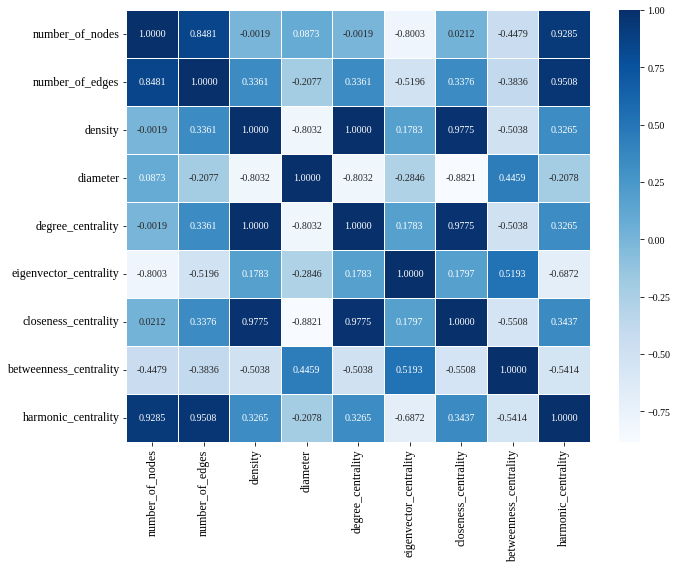

In [32]:
distance_function = 'lance_williams'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])
# current_data = current_data.dropna()
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Lance Williams*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (lw) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)

#### **25th percentile**

<br>Number of data points: 17888

<br>Correlation Matrix (*Euclidean 25th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.951402 | -0.726248 |   0.616159 |           -0.726248 |               -0.826663  |              -0.655155 |               -0.294829  |              0.935442 |
| number_of_edges        |          0.951402 |          1        | -0.569831 |   0.390363 |           -0.569831 |               -0.717239  |              -0.459986 |               -0.474276  |              0.97809  |
| density                |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| diameter               |          0.616159 |          0.390363 | -0.765701 |   1        |           -0.765701 |               -0.699323  |              -0.862945 |                0.399477  |              0.363075 |
| degree_centrality      |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| eigenvector_centrality |         -0.826663 |         -0.717239 |  0.901196 |  -0.699323 |            0.901196 |                1         |               0.852577 |                0.0824432 |             -0.789565 |
| closeness_centrality   |         -0.655155 |         -0.459986 |  0.97078  |  -0.862945 |            0.97078  |                0.852577  |               1        |               -0.410551  |             -0.489763 |
| betweenness_centrality |         -0.294829 |         -0.474276 | -0.276351 |   0.399477 |           -0.276351 |                0.0824432 |              -0.410551 |                1         |             -0.515771 |
| harmonic_centrality    |          0.935442 |          0.97809  | -0.618186 |   0.363075 |           -0.618186 |               -0.789565  |              -0.489763 |               -0.515771  |              1        |

<br>

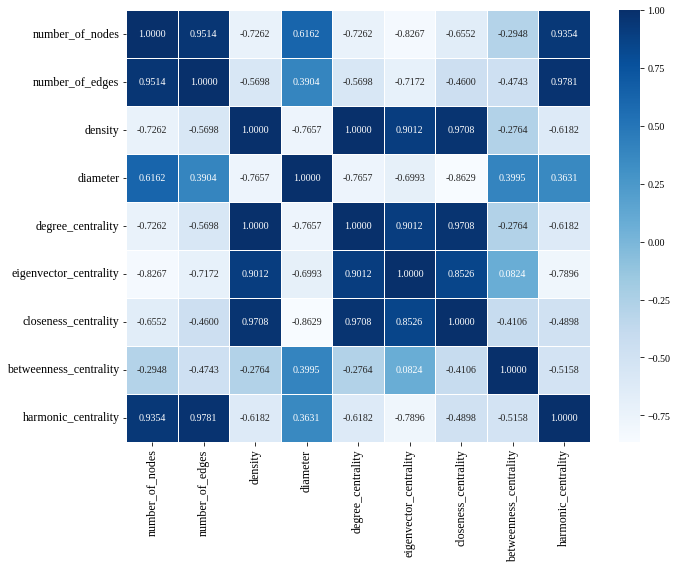

In [43]:
distance_intervals = [
    'lance_williams (0, 10)' 
]

distance_function = 'lance_williams'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Lance Williams 25th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (lw_p25) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **50th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 50th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.923347 | -0.666278 |   0.549386 |           -0.666278 |               -0.84011   |              -0.611126 |               -0.141032  |              0.955633 |
| number_of_edges        |          0.923347 |          1        | -0.419797 |   0.265975 |           -0.419797 |               -0.67485   |              -0.341435 |               -0.327691  |              0.965967 |
| density                |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| diameter               |          0.549386 |          0.265975 | -0.848733 |   1        |           -0.848733 |               -0.652225  |              -0.903341 |                0.580956  |              0.339196 |
| degree_centrality      |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| eigenvector_centrality |         -0.84011  |         -0.67485  |  0.809435 |  -0.652225 |            0.809435 |                1         |               0.769843 |               -0.0935803 |             -0.814468 |
| closeness_centrality   |         -0.611126 |         -0.341435 |  0.986711 |  -0.903341 |            0.986711 |                0.769843  |               1        |               -0.628964  |             -0.440111 |
| betweenness_centrality |         -0.141032 |         -0.327691 | -0.569603 |   0.580956 |           -0.569603 |               -0.0935803 |              -0.628964 |                1         |             -0.312402 |
| harmonic_centrality    |          0.955633 |          0.965967 | -0.520454 |   0.339196 |           -0.520454 |               -0.814468  |              -0.440111 |               -0.312402  |              1        |

<br>

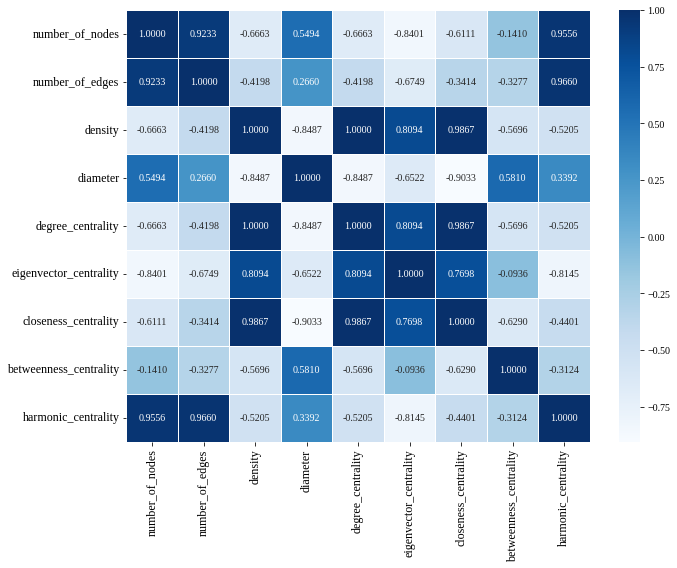

In [46]:
distance_intervals = [
    'lance_williams (0, 15)' 
]

distance_function = 'lance_williams'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Lance Williams 50th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (lw_p50) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **75th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 75th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |         1         |          0.918804 | -0.568517 |   0.511931 |           -0.568517 |                -0.844    |              -0.549926 |               -0.0323088 |              0.968408 |
| number_of_edges        |         0.918804  |          1        | -0.299105 |   0.233424 |           -0.299105 |                -0.659664 |              -0.272314 |               -0.223373  |              0.956321 |
| density                |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| diameter               |         0.511931  |          0.233424 | -0.88061  |   1        |           -0.88061  |                -0.617536 |              -0.904459 |                0.6721    |              0.339523 |
| degree_centrality      |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| eigenvector_centrality |        -0.844     |         -0.659664 |  0.672539 |  -0.617536 |            0.672539 |                 1        |               0.660708 |               -0.18195   |             -0.826768 |
| closeness_centrality   |        -0.549926  |         -0.272314 |  0.995555 |  -0.904459 |            0.995555 |                 0.660708 |               1        |               -0.758946  |             -0.381077 |
| betweenness_centrality |        -0.0323088 |         -0.223373 | -0.743344 |   0.6721   |           -0.743344 |                -0.18195  |              -0.758946 |                1         |             -0.181099 |
| harmonic_centrality    |         0.968408  |          0.956321 | -0.406749 |   0.339523 |           -0.406749 |                -0.826768 |              -0.381077 |               -0.181099  |              1        |

<br>

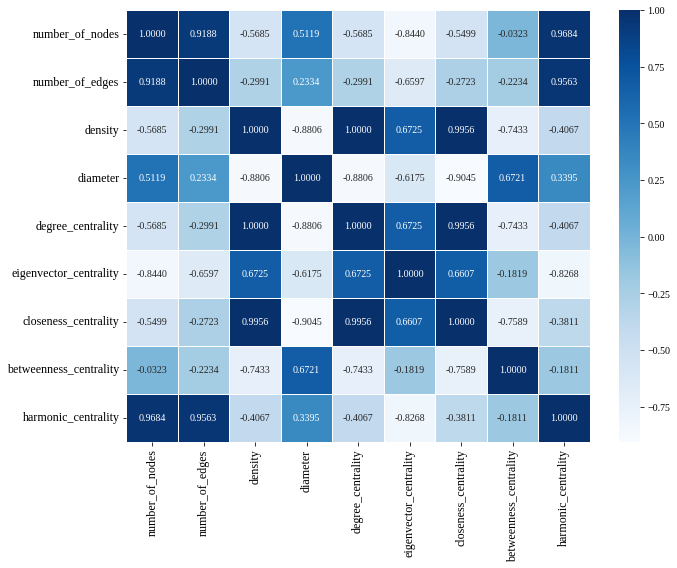

In [45]:
distance_intervals = [
    'lance_williams (0, 20)' 
]

distance_function = 'lance_williams'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Lance Williams 75th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (lw_p75) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **Soergel**

<br>Number of data points: 17907

<br>Correlation Matrix (*Soergel*)

|                        |   number_of_nodes |   number_of_edges |     density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|------------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |        1          |          0.848189 | -0.00152866 |  0.0869335 |         -0.00152866 |                -0.800267 |              0.0216128 |                -0.448303 |              0.92856  |
| number_of_edges        |        0.848189   |          1        |  0.336227   | -0.207989  |          0.336227   |                -0.51965  |              0.337799  |                -0.383819 |              0.9508   |
| density                |       -0.00152866 |          0.336227 |  1          | -0.80303   |          1          |                 0.177864 |              0.977469  |                -0.503575 |              0.326682 |
| diameter               |        0.0869335  |         -0.207989 | -0.80303    |  1         |         -0.80303    |                -0.28432  |             -0.882089  |                 0.445422 |             -0.208039 |
| degree_centrality      |       -0.00152866 |          0.336227 |  1          | -0.80303   |          1          |                 0.177864 |              0.977469  |                -0.503575 |              0.326682 |
| eigenvector_centrality |       -0.800267   |         -0.51965  |  0.177864   | -0.28432   |          0.177864   |                 1        |              0.179395  |                 0.520057 |             -0.687285 |
| closeness_centrality   |        0.0216128  |          0.337799 |  0.977469   | -0.882089  |          0.977469   |                 0.179395 |              1         |                -0.550509 |              0.343838 |
| betweenness_centrality |       -0.448303   |         -0.383819 | -0.503575   |  0.445422  |         -0.503575   |                 0.520057 |             -0.550509  |                 1        |             -0.541597 |
| harmonic_centrality    |        0.92856    |          0.9508   |  0.326682   | -0.208039  |          0.326682   |                -0.687285 |              0.343838  |                -0.541597 |              1        |

<br>

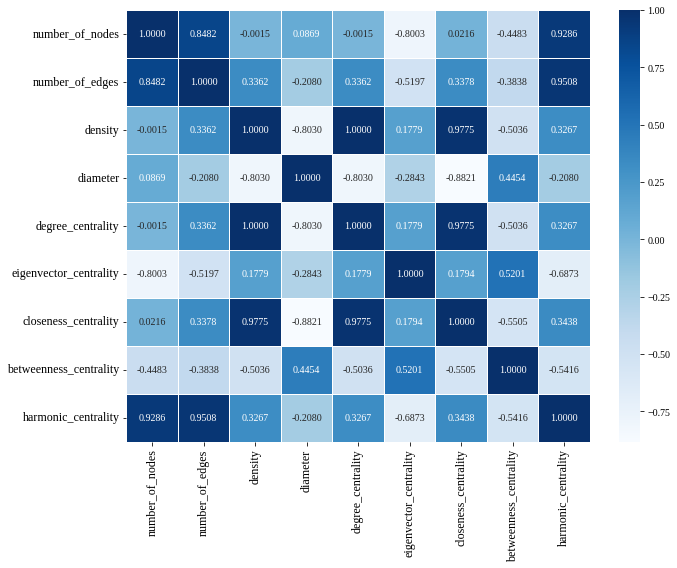

In [49]:
distance_function = 'soergel'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])
# current_data = current_data.dropna()
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Soergel*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (so) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)

#### **25th percentile**

<br>Number of data points: 17888

<br>Correlation Matrix (*Euclidean 25th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.951402 | -0.726248 |   0.616159 |           -0.726248 |               -0.826663  |              -0.655155 |               -0.294829  |              0.935442 |
| number_of_edges        |          0.951402 |          1        | -0.569831 |   0.390363 |           -0.569831 |               -0.717239  |              -0.459986 |               -0.474276  |              0.97809  |
| density                |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| diameter               |          0.616159 |          0.390363 | -0.765701 |   1        |           -0.765701 |               -0.699323  |              -0.862945 |                0.399477  |              0.363075 |
| degree_centrality      |         -0.726248 |         -0.569831 |  1        |  -0.765701 |            1        |                0.901196  |               0.97078  |               -0.276351  |             -0.618186 |
| eigenvector_centrality |         -0.826663 |         -0.717239 |  0.901196 |  -0.699323 |            0.901196 |                1         |               0.852577 |                0.0824432 |             -0.789565 |
| closeness_centrality   |         -0.655155 |         -0.459986 |  0.97078  |  -0.862945 |            0.97078  |                0.852577  |               1        |               -0.410551  |             -0.489763 |
| betweenness_centrality |         -0.294829 |         -0.474276 | -0.276351 |   0.399477 |           -0.276351 |                0.0824432 |              -0.410551 |                1         |             -0.515771 |
| harmonic_centrality    |          0.935442 |          0.97809  | -0.618186 |   0.363075 |           -0.618186 |               -0.789565  |              -0.489763 |               -0.515771  |              1        |

<br>

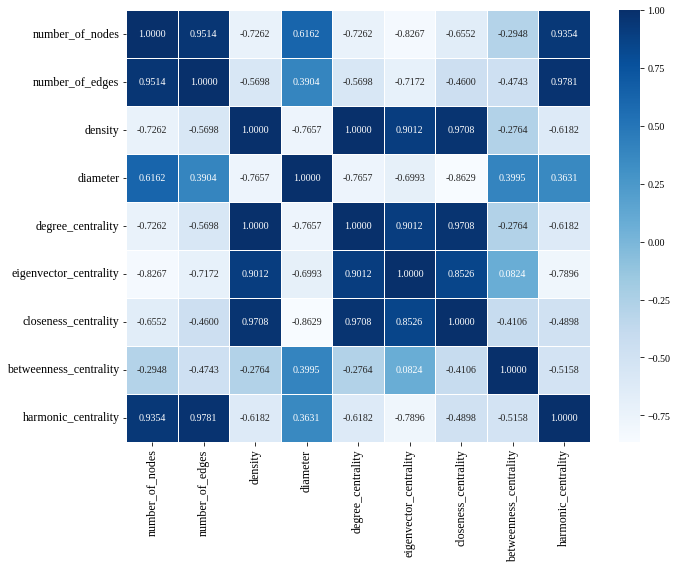

In [43]:
distance_intervals = [
    'soergel (0, 10)' 
]

distance_function = 'soergel'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Soergel 25th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (so_p25) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **50th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 50th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |          1        |          0.923347 | -0.666278 |   0.549386 |           -0.666278 |               -0.84011   |              -0.611126 |               -0.141032  |              0.955633 |
| number_of_edges        |          0.923347 |          1        | -0.419797 |   0.265975 |           -0.419797 |               -0.67485   |              -0.341435 |               -0.327691  |              0.965967 |
| density                |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| diameter               |          0.549386 |          0.265975 | -0.848733 |   1        |           -0.848733 |               -0.652225  |              -0.903341 |                0.580956  |              0.339196 |
| degree_centrality      |         -0.666278 |         -0.419797 |  1        |  -0.848733 |            1        |                0.809435  |               0.986711 |               -0.569603  |             -0.520454 |
| eigenvector_centrality |         -0.84011  |         -0.67485  |  0.809435 |  -0.652225 |            0.809435 |                1         |               0.769843 |               -0.0935803 |             -0.814468 |
| closeness_centrality   |         -0.611126 |         -0.341435 |  0.986711 |  -0.903341 |            0.986711 |                0.769843  |               1        |               -0.628964  |             -0.440111 |
| betweenness_centrality |         -0.141032 |         -0.327691 | -0.569603 |   0.580956 |           -0.569603 |               -0.0935803 |              -0.628964 |                1         |             -0.312402 |
| harmonic_centrality    |          0.955633 |          0.965967 | -0.520454 |   0.339196 |           -0.520454 |               -0.814468  |              -0.440111 |               -0.312402  |              1        |

<br>

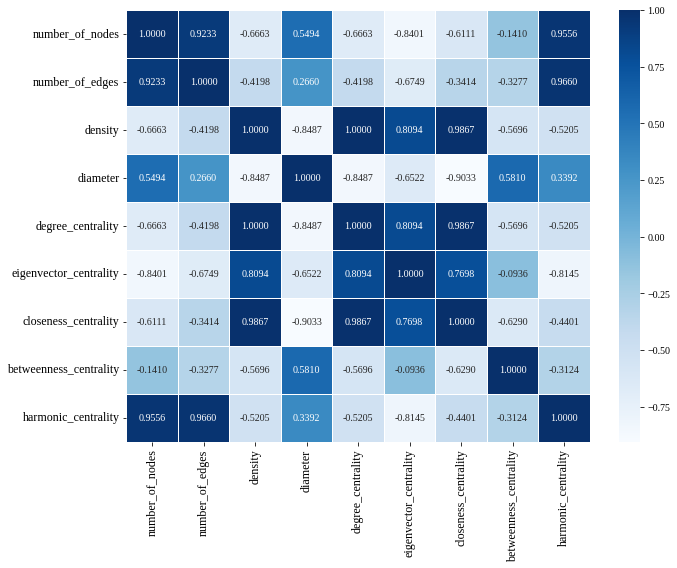

In [46]:
distance_intervals = [
    'soergel (0, 15)' 
]

distance_function = 'soergel'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Soergel 50th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (so_p50) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()

#### **75th percentile**

<br>Number of data points: 17889

<br>Correlation Matrix (*Euclidean 75th Percentile*)

|                        |   number_of_nodes |   number_of_edges |   density |   diameter |   degree_centrality |   eigenvector_centrality |   closeness_centrality |   betweenness_centrality |   harmonic_centrality |
|:-----------------------|------------------:|------------------:|----------:|-----------:|--------------------:|-------------------------:|-----------------------:|-------------------------:|----------------------:|
| number_of_nodes        |         1         |          0.918804 | -0.568517 |   0.511931 |           -0.568517 |                -0.844    |              -0.549926 |               -0.0323088 |              0.968408 |
| number_of_edges        |         0.918804  |          1        | -0.299105 |   0.233424 |           -0.299105 |                -0.659664 |              -0.272314 |               -0.223373  |              0.956321 |
| density                |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| diameter               |         0.511931  |          0.233424 | -0.88061  |   1        |           -0.88061  |                -0.617536 |              -0.904459 |                0.6721    |              0.339523 |
| degree_centrality      |        -0.568517  |         -0.299105 |  1        |  -0.88061  |            1        |                 0.672539 |               0.995555 |               -0.743344  |             -0.406749 |
| eigenvector_centrality |        -0.844     |         -0.659664 |  0.672539 |  -0.617536 |            0.672539 |                 1        |               0.660708 |               -0.18195   |             -0.826768 |
| closeness_centrality   |        -0.549926  |         -0.272314 |  0.995555 |  -0.904459 |            0.995555 |                 0.660708 |               1        |               -0.758946  |             -0.381077 |
| betweenness_centrality |        -0.0323088 |         -0.223373 | -0.743344 |   0.6721   |           -0.743344 |                -0.18195  |              -0.758946 |                1         |             -0.181099 |
| harmonic_centrality    |         0.968408  |          0.956321 | -0.406749 |   0.339523 |           -0.406749 |                -0.826768 |              -0.381077 |               -0.181099  |              1        |

<br>

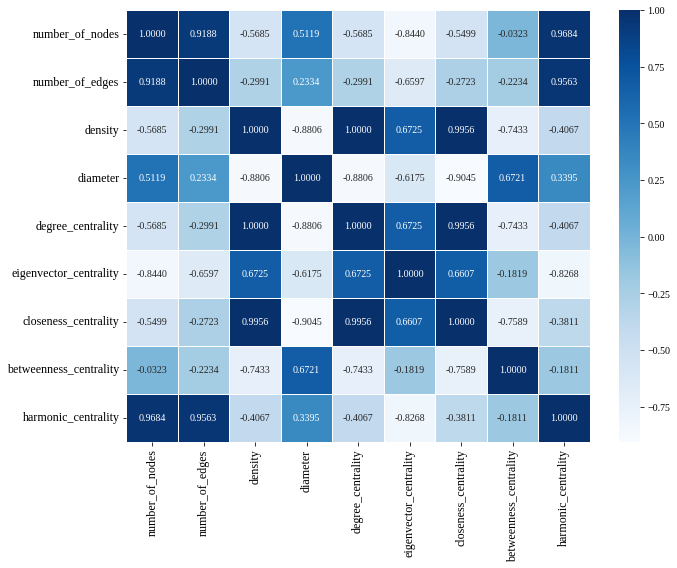

In [45]:
distance_intervals = [
    'soergel (0, 20)' 
]

distance_function = 'soergel'
current_data = data[(data['distance_function'] == distance_function)].copy()
current_data = current_data[current_data['distance_interval'].isin(distance_intervals)].copy()  

current_data = current_data.select_dtypes(include=['number'])
current_data = current_data.drop(columns=['number_of_connected_components'])
current_data = current_data.dropna(subset=['eigenvector_centrality'])


current_data = current_data.select_dtypes(include=['number'])
corr = current_data.corr(method="pearson")

display(Markdown(f"<br>Number of data points: {len(current_data)}"))

display(Markdown("<br>Correlation Matrix (*Soergel 75th Percentile*)"))
display(Markdown(corr.to_markdown()))
output = paths['graph_metrics_path'].joinpath("Metric Correlation (so_p75) -heatmap")
fig_size=(10, 8)
font_size=12
cmap="Blues"

display(Markdown("<br>"))
plt = heatmap(corr, output=output, fig_size=fig_size, font_size=font_size, cmap=cmap)
plt.show()